In [1]:
import numpy as np
import pandas as pd
import warnings
import graphviz
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import  train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score
import joblib
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, mean_squared_error
from typing import List, Dict, Union, Optional
import warnings
warnings.filterwarnings('ignore')


In [2]:
class tree_family():
    def __init__(self, df):
        self.df = pd.read_csv(df)
    def split_df_X_Y(self, name_of_column):
        self.x = self.df.drop(name_of_column,axis=1)
        self.y = self.df[name_of_column]
    def split_train_test(self,test_size=0.3):
        self.x_train, self.x_test, self.y_train, self.y_test = train_test_split(self.x, self.y, test_size=test_size, stratify=None,random_state=42)
    def DecisionTreeClassifier(self,max_depth=4, bool_save = True, class_weight = "balanced"):
        

        print("DecisionTreeClassifier\n\n")
        clf = DecisionTreeClassifier(random_state = 42,max_depth = max_depth,class_weight= class_weight)
        clf.fit(self.x_train, self.y_train)
        prediction = clf.predict(self.x_test)
        tree_family.metrix(self,prediction, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/DecisionTreeClassifier_with_new_1_category_people_EEG.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")

    def RandomForestClassifier(self,n_estimators=200,max_depth = 4,bool_save = True,class_weight_ = "balanced"):
        
        print("RandomForestClassifier\n\n")
        print(max_depth)
        clf = RandomForestClassifier(n_estimators=n_estimators,random_state = 42,max_depth = max_depth,class_weight= class_weight_)
        clf.fit(self.x_train, self.y_train)
        y_pred = clf.predict(self.x_test)
        tree_family.metrix(self,y_pred, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/RandomForestClassifier_with_new_1_category_people_EEG.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")
    def GradientBoostingClassifier(self, n_estimators=200, max_depth=3, bool_save = True):
        print("GradientBoostingClassifier\n\n")


        clf = GradientBoostingClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        # Создаем веса для каждой строки обучающей выборки
        # weights = y_train.iloc[:, 0].map({0: 1, 1: 6})


        clf.fit(self.x_train, self.y_train)
        y_pred = clf.predict(self.x_test)
        tree_family.metrix(self,y_pred, clf)
        if bool_save:
            joblib.dump(clf, 'saved_model/GradientBoostingClassifier_with_new_1_category_people_EEG.pkl')
            print("SUCCESSFUL SAVE")

        else:
            print("SAVE TURN OFF")


    def metrix(self,prediction,clf):
        from sklearn.model_selection import cross_val_score
        accuracy_score(prediction, self.y_test)
        print(f"Accuracy:{accuracy_score(self.y_test, prediction):.3f}")
        print(f"Precision:{precision_score(self.y_test, prediction):.3f}")
        print(f"Recall:  {recall_score(self.y_test, prediction):.3f}")
        print(f"F1-score: {f1_score(self.y_test, prediction):.3f}")
        # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
        print("\nConfusion Matrix:\n", confusion_matrix(self.y_test, prediction))
        print("\nClassification Report:\n", classification_report(self.y_test, prediction))


        scores_f1 = cross_val_score(clf, self.x, self.y, cv=5, scoring='f1')

        print(f"F1-результаты по фолдам: {scores_f1}")
        print(f"Средний F1: {scores_f1.mean():.2f}")
        from sklearn import metrics
        fpr, tpr, _ = metrics.roc_curve(self.y_test,  prediction)

        # построение ROC кривой
        plt.plot(fpr, tpr)
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.show()
        return

In [5]:
def metrix(y_test,prediction,clf):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    # scores_f1 = cross_val_score(clf, x, y, cv=5, scoring='f1')

    # print(f"F1-результаты по фолдам: {scores_f1}")
    # print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return

In [3]:
# EGG_data_spliting_with_new_1_category = tree_family(r"C:\Users\a.v.nasirov\Desktop\UDGU_project\EEG_files\data_for_EEG\df_with_new_1_category_EEG.csv")
# EGG_data_spliting_with_new_1_category.split_df_X_Y("здоров(1)/болен(0)")
# EGG_data_spliting_with_new_1_category.split_train_test()
# EGG_data_spliting_with_new_1_category.DecisionTreeClassifier(max_depth = 12,bool_save = False)
# EGG_data_spliting_with_new_1_category.RandomForestClassifier(n_estimators= 300,max_depth = 12,bool_save = False)
# EGG_data_spliting_with_new_1_category.GradientBoostingClassifier(n_estimators = 300,max_depth = 12,bool_save = False)

In [4]:
# df = pd.read_csv(r"/home/ikuku/UDGU_project/main/EEG_files/data_for_EEG/df_with_new_1_category_EEG.csv")

In [5]:
# df.info(verbose=True)
# 

если мы делим датасет на два, один из которых делиться на train выборку и в котором по 44 строки каждого класса то в test выборке не остаеться настоящих людей малочисленного класса :(

In [2]:
df_train = pd.read_csv("df_balanced.csv")
df_test = pd.read_csv("data_for_EEG/df_leftovers.csv")

In [4]:

x_train = df_train.drop('здоров(1)/болен(0)', axis=1)
y_train = df_train['здоров(1)/болен(0)']

# Тестовая выборка (из второго датасета)
x_test = df_test.drop('здоров(1)/болен(0)', axis=1)
y_test = df_test['здоров(1)/болен(0)']


DecisionTreeClassifier


Accuracy:0.571
Precision:0.000
Recall:  0.000
F1-score: 0.000

Confusion Matrix:
 [[56 42]
 [ 0  0]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.57      0.73        98
           1       0.00      0.00      0.00         0

    accuracy                           0.57        98
   macro avg       0.50      0.29      0.36        98
weighted avg       1.00      0.57      0.73        98



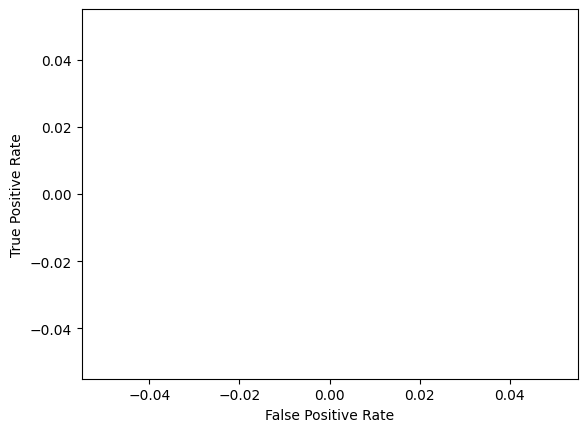

In [6]:
print("DecisionTreeClassifier\n\n")
clf = DecisionTreeClassifier(random_state = 42,max_depth = 10)
clf.fit(x_train, y_train)
prediction = clf.predict(x_test)
metrix(y_test,prediction, clf)

DecisionTreeClassifier


Accuracy:0.519
Precision:0.667
Recall:  0.471
F1-score: 0.552

Confusion Matrix:
 [[6 4]
 [9 8]]

Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.60      0.48        10
           1       0.67      0.47      0.55        17

    accuracy                           0.52        27
   macro avg       0.53      0.54      0.52        27
weighted avg       0.57      0.52      0.53        27

F1-результаты по фолдам: [0.53333333 0.42105263 0.58823529 0.53333333 0.53333333]
Средний F1: 0.52


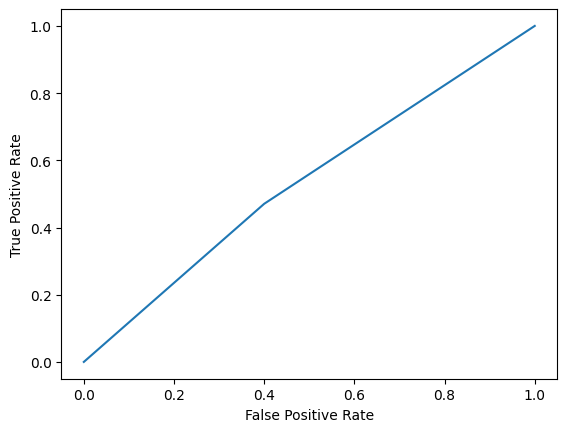

SAVE TURN OFF
RandomForestClassifier


20
Accuracy:0.556
Precision:0.727
Recall:  0.471
F1-score: 0.571

Confusion Matrix:
 [[7 3]
 [9 8]]

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.70      0.54        10
           1       0.73      0.47      0.57        17

    accuracy                           0.56        27
   macro avg       0.58      0.59      0.55        27
weighted avg       0.62      0.56      0.56        27

F1-результаты по фолдам: [0.73684211 0.55555556 0.5        0.63157895 0.53333333]
Средний F1: 0.59


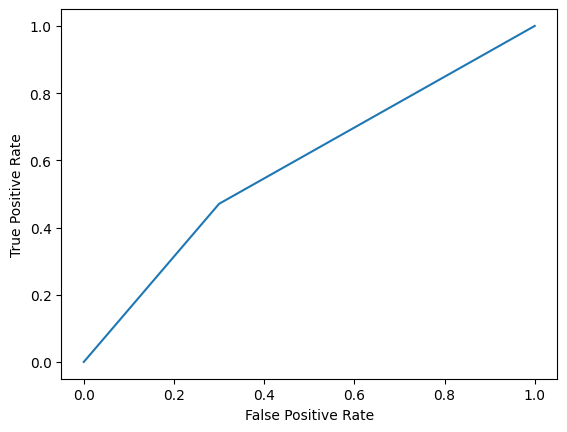

SAVE TURN OFF
GradientBoostingClassifier


Accuracy:0.593
Precision:0.688
Recall:  0.647
F1-score: 0.667

Confusion Matrix:
 [[ 5  5]
 [ 6 11]]

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.50      0.48        10
           1       0.69      0.65      0.67        17

    accuracy                           0.59        27
   macro avg       0.57      0.57      0.57        27
weighted avg       0.60      0.59      0.60        27

F1-результаты по фолдам: [0.70588235 0.5        0.66666667 0.53333333 0.18181818]
Средний F1: 0.52


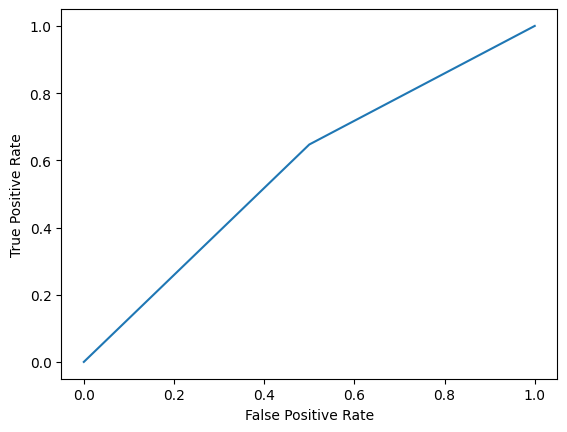

SAVE TURN OFF


In [6]:
EGG_balanced_data = tree_family("df_balanced.csv")
EGG_balanced_data.split_df_X_Y("здоров(1)/болен(0)")
EGG_balanced_data.split_train_test()
EGG_balanced_data.DecisionTreeClassifier(max_depth = 20,bool_save = False)
EGG_balanced_data.RandomForestClassifier(n_estimators= 300,max_depth = 20,bool_save = False)
EGG_balanced_data.GradientBoostingClassifier(n_estimators = 300,max_depth = 20,bool_save = False)

DecisionTreeClassifier


Accuracy:0.750
Precision:0.429
Recall:  0.500
F1-score: 0.462

Confusion Matrix:
 [[36  8]
 [ 6  6]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84        44
           1       0.43      0.50      0.46        12

    accuracy                           0.75        56
   macro avg       0.64      0.66      0.65        56
weighted avg       0.77      0.75      0.76        56

F1-результаты по фолдам: [0.5        0.4        0.7        0.33333333 0.22222222]
Средний F1: 0.43


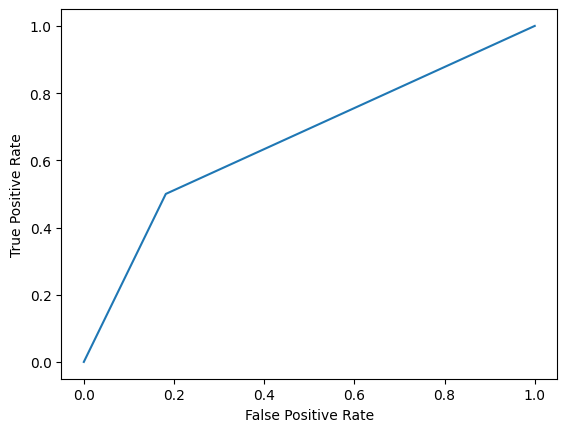

SAVE TURN OFF
RandomForestClassifier


20
Accuracy:0.786
Precision:0.000
Recall:  0.000
F1-score: 0.000

Confusion Matrix:
 [[44  0]
 [12  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      1.00      0.88        44
           1       0.00      0.00      0.00        12

    accuracy                           0.79        56
   macro avg       0.39      0.50      0.44        56
weighted avg       0.62      0.79      0.69        56

F1-результаты по фолдам: [0. 0. 0. 0. 0.]
Средний F1: 0.00


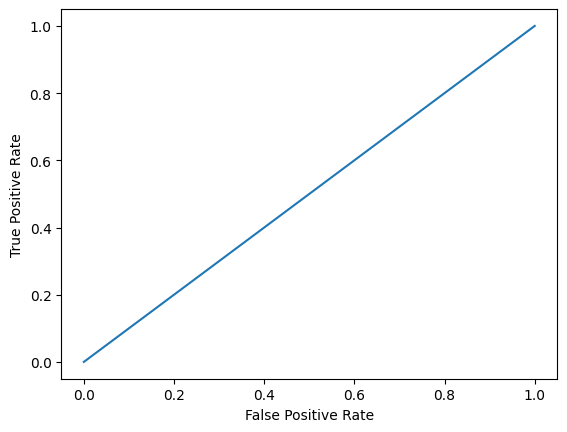

SAVE TURN OFF
GradientBoostingClassifier


Accuracy:0.679
Precision:0.250
Recall:  0.250
F1-score: 0.250

Confusion Matrix:
 [[35  9]
 [ 9  3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        44
           1       0.25      0.25      0.25        12

    accuracy                           0.68        56
   macro avg       0.52      0.52      0.52        56
weighted avg       0.68      0.68      0.68        56

F1-результаты по фолдам: [0.26666667 0.35294118 0.17391304 0.47058824 0.31578947]
Средний F1: 0.32


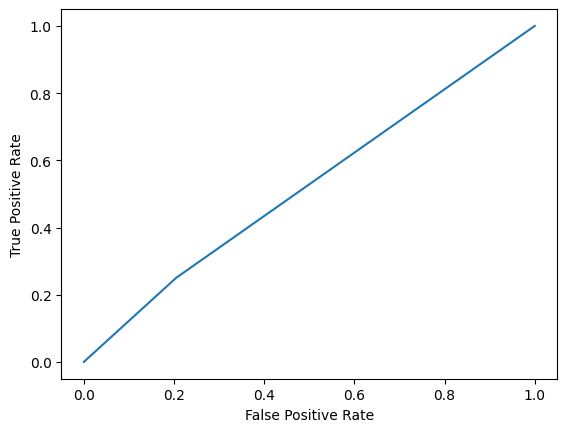

SAVE TURN OFF


In [47]:
EGG_data = tree_family(r"C:\Users\a.v.nasirov\Desktop\UDGU_project\EEG_files\data_for_EEG\combined_horizontal_data.csv")
EGG_data.split_df_X_Y("здоров(1)/болен(0)")
EGG_data.split_train_test()
EGG_data.DecisionTreeClassifier(max_depth = 20,bool_save = False,class_weight= {0:1,1:4})
EGG_data.RandomForestClassifier(n_estimators= 300,max_depth = 20,bool_save = False,class_weight_= {0:1,1:4})
EGG_data.GradientBoostingClassifier(n_estimators = 300,max_depth = 20,bool_save = False)

In [ ]:
df = pd.read_csv(r"C:\Users\a.v.nasirov\Desktop\UDGU_project\EEG_files\data_for_EEG\df_with_new_1_category_EEG.csv")
x = df.drop("здоров(1)/болен(0)",axis=1)
y = df["здоров(1)/болен(0)"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=None,random_state=42)

In [6]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=1
    )

    score = cross_val_score(model, x_train, y_train, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

c:\Users\a.v.nasirov\.conda\envs\UDGU_project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-16 17:14:17,894] A new study created in memory with name: no-name-a3c93efe-3fea-4293-9013-fe7defcb6a42
[I 2026-04-16 17:14:18,263] Trial 0 finished with value: 0.8083333333333332 and parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8083333333333332.
[I 2026-04-16 17:14:18,471] Trial 1 finished with value: 0.7121794871794871 and parameters: {'max_depth': 20, 'min_samples_leaf': 20, 'min_samples_split': 13, 'criterion': 'gini'}. Best is trial 0 with value: 0.8083333333333332.
[I 2026-04-16 17:14:18,839] Trial 2 finished with value: 0.8083333333333332 and parameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 9, 'cr

Best params: {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 7, 'criterion': 'entropy'}
Best score: 0.8233333333333335


In [8]:
df = pd.read_csv(r"C:\Users\a.v.nasirov\Desktop\UDGU_project\EEG_files\data_for_EEG\combined_horizontal_data.csv")
x = df.drop("здоров(1)/болен(0)",axis=1)
y = df["здоров(1)/болен(0)"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=None,random_state=42)
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int("max_depth", 1, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 30)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=1
    )

    score = cross_val_score(model, x_train, y_train, cv=5).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-04-16 17:17:19,739] A new study created in memory with name: no-name-fa9879e0-0350-4d59-b8a4-57620e91adea
[I 2026-04-16 17:17:19,874] Trial 0 finished with value: 0.8076923076923077 and parameters: {'max_depth': 14, 'min_samples_leaf': 22, 'min_samples_split': 15, 'criterion': 'gini'}. Best is trial 0 with value: 0.8076923076923077.
[I 2026-04-16 17:17:20,075] Trial 1 finished with value: 0.7923076923076923 and parameters: {'max_depth': 10, 'min_samples_leaf': 12, 'min_samples_split': 7, 'criterion': 'entropy'}. Best is trial 0 with value: 0.8076923076923077.
[I 2026-04-16 17:17:20,222] Trial 2 finished with value: 0.8076923076923077 and parameters: {'max_depth': 9, 'min_samples_leaf': 15, 'min_samples_split': 20, 'criterion': 'gini'}. Best is trial 0 with value: 0.8076923076923077.
[I 2026-04-16 17:17:20,339] Trial 3 finished with value: 0.7846153846153846 and parameters: {'max_depth': 13, 'min_samples_leaf': 26, 'min_samples_split': 7, 'criterion': 'gini'}. Best is trial 0 wi

Best params: {'max_depth': 4, 'min_samples_leaf': 22, 'min_samples_split': 14, 'criterion': 'entropy'}
Best score: 0.8615384615384615


In [11]:
class StackingEnsemble:
    """
    Универсальный стекинг ансамбль для классификации и регрессии
    """
    
    def __init__(self, 
                 base_models: List,
                 meta_model,
                 n_folds: int = 5,
                 use_probas: bool = False,
                 regression: bool = False,
                 random_state: int = 42):
        """
        Параметры:
        -----------
        base_models: список базовых моделей
        meta_model: мета-модель (финальный блендер)
        n_folds: количество фолдов для кросс-валидации
        use_probas: использовать вероятности (для классификации)
        regression: True для регрессии, False для классификации
        random_state: random seed
        """
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds
        self.use_probas = use_probas
        self.regression = regression
        self.random_state = random_state
        self.base_models_trained = []
        self.meta_model_trained = None
        self.feature_names = None
        
    def fit(self, X, y):
        """
        Обучение стекинг ансамбля
        """
        X = np.array(X)
        y = np.array(y)
        
        # Сохраняем названия признаков если есть
        if hasattr(X, 'columns'):
            self.feature_names = list(X.columns)
        
        # Матрица для предсказаний базовых моделей
        n_samples = X.shape[0]
        
        if self.regression:
            n_meta_features = len(self.base_models)
        else:
            if self.use_probas:
                n_classes = len(np.unique(y))
                n_meta_features = len(self.base_models) * n_classes
            else:
                n_meta_features = len(self.base_models)
        
        meta_features = np.zeros((n_samples, n_meta_features))
        
        # Обучение базовых моделей с кросс-валидацией
        print("Обучение базовых моделей...")
        kf = self._get_kfold()
        
        for i, model in enumerate(self.base_models):
            print(f"  Модель {i+1}/{len(self.base_models)}: {type(model).__name__}")
            
            # Создаем копию модели для обучения
            model_clone = self._clone_model(model)
            self.base_models_trained.append(model_clone)
            
            # Полное обучение модели на всех данных
            model_clone.fit(X, y)
            
            # Кросс-валидация для получения out-of-fold предсказаний
            fold_predictions = np.zeros(n_samples)
            
            for train_idx, val_idx in kf.split(X, y):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train = y[train_idx]
                
                # Обучаем на фолде
                fold_model = self._clone_model(model)
                fold_model.fit(X_train, y_train)
                
                # Предсказываем на валидационном фолде
                if self.regression:
                    pred = fold_model.predict(X_val)
                else:
                    if self.use_probas:
                        pred = fold_model.predict_proba(X_val)
                        # Для бинарной классификации берем вероятность положительного класса
                        if pred.shape[1] == 2:
                            pred = pred[:, 1]
                        else:
                            # Для многоклассовой - все вероятности
                            pred = pred.reshape(-1, n_classes)
                    else:
                        pred = fold_model.predict(X_val)
                
                fold_predictions[val_idx] = pred
            
            # Сохраняем out-of-fold предсказания как фичи для мета-модели
            if self.regression:
                meta_features[:, i] = fold_predictions
            else:
                if self.use_probas:
                    if len(fold_predictions.shape) == 1:
                        meta_features[:, i] = fold_predictions
                    else:
                        start_idx = i * n_classes
                        end_idx = (i + 1) * n_classes
                        meta_features[:, start_idx:end_idx] = fold_predictions
                else:
                    meta_features[:, i] = fold_predictions
        
        # Обучение мета-модели на предсказаниях базовых моделей
        print("\nОбучение мета-модели...")
        self.meta_model_trained = self._clone_model(self.meta_model)
        self.meta_model_trained.fit(meta_features, y)
        
        return self
    
    def predict(self, X):
        """
        Предсказание стекинг ансамбля
        """
        X = np.array(X)
        
        # Получаем предсказания от базовых моделей
        base_predictions = self._get_base_predictions(X)
        
        # Предсказание мета-модели
        final_prediction = self.meta_model_trained.predict(base_predictions)
        
        return final_prediction
    
    def predict_proba(self, X):
        """
        Предсказание вероятностей (для классификации)
        """
        if self.regression:
            raise ValueError("Метод predict_proba доступен только для классификации")
        
        X = np.array(X)
        base_predictions = self._get_base_predictions(X)
        
        if hasattr(self.meta_model_trained, 'predict_proba'):
            return self.meta_model_trained.predict_proba(base_predictions)
        else:
            raise ValueError("Мета-модель не поддерживает predict_proba")
    
    def _get_base_predictions(self, X):
        """
        Получение предсказаний от всех базовых моделей
        """
        n_samples = X.shape[0]
        
        if self.regression:
            n_meta_features = len(self.base_models)
        else:
            if self.use_probas:
                n_classes = len(np.unique(
                    self.base_models_trained[0].classes_ 
                    if hasattr(self.base_models_trained[0], 'classes_') 
                    else np.unique([model.predict(X) for model in self.base_models_trained])
                ))
                n_meta_features = len(self.base_models) * n_classes
            else:
                n_meta_features = len(self.base_models)
        
        base_predictions = np.zeros((n_samples, n_meta_features))
        
        for i, model in enumerate(self.base_models_trained):
            if self.regression:
                pred = model.predict(X)
                base_predictions[:, i] = pred
            else:
                if self.use_probas:
                    pred_proba = model.predict_proba(X)
                    if pred_proba.shape[1] == 2:
                        base_predictions[:, i] = pred_proba[:, 1]
                    else:
                        start_idx = i * n_classes
                        end_idx = (i + 1) * n_classes
                        base_predictions[:, start_idx:end_idx] = pred_proba
                else:
                    pred = model.predict(X)
                    base_predictions[:, i] = pred
        
        return base_predictions
    
    def _get_kfold(self):
        """Создание стратегии кросс-валидации"""
        if self.regression:
            return KFold(n_splits=self.n_folds, shuffle=True, 
                        random_state=self.random_state)
        else:
            return StratifiedKFold(n_splits=self.n_folds, shuffle=True, 
                                 random_state=self.random_state)
    
    def _clone_model(self, model):
        """Клонирование модели"""
        from sklearn.base import clone
        return clone(model)
    
    def get_feature_importances(self):
        """
        Получение важности фичей от мета-модели
        """
        if hasattr(self.meta_model_trained, 'feature_importances_'):
            return self.meta_model_trained.feature_importances_
        elif hasattr(self.meta_model_trained, 'coef_'):
            return np.abs(self.meta_model_trained.coef_).mean(axis=0)
        else:
            return None
    
    def get_model_weights(self):
        """
        Получение весов моделей в ансамбле
        """
        importances = self.get_feature_importances()
        if importances is not None:
            model_weights = {}
            n_models = len(self.base_models)
            
            if self.regression or not self.use_probas:
                for i, model in enumerate(self.base_models):
                    model_name = type(model).__name__
                    model_weights[model_name] = importances[i] if i < len(importances) else 0
            else:
                # Для многоклассовой классификации с вероятностями
                n_classes = len(self.base_models_trained[0].classes_)
                for i, model in enumerate(self.base_models):
                    model_name = type(model).__name__
                    start_idx = i * n_classes
                    end_idx = (i + 1) * n_classes
                    model_weights[model_name] = np.mean(importances[start_idx:end_idx])
            
            return model_weights
        return None

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [ ]:
def create_classification_stack():
    """
    Создание стекинг ансамбля для классификации
    """
    # Базовые модели
    base_models = [
        RandomForestClassifier(n_estimators=100, random_state=42),
        GradientBoostingClassifier(n_estimators=100, random_state=42),
        XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, 
                     eval_metric='logloss'),
        LGBMClassifier(n_estimators=100, random_state=42),
        SVC(probability=True, random_state=42),
        KNeighborsClassifier(n_neighbors=7),
        GaussianNB(),
        MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
    ]
    
    # Мета-модель
    meta_model = LogisticRegression(random_state=42, max_iter=1000)
    
    # Создаем стекинг ансамбль
    stack = StackingEnsemble(
        base_models=base_models,
        meta_model=meta_model,
        n_folds=5,
        use_probas=True,
        regression=False,
        random_state=42
    )
    
    return stack
